# Abstract

El siguiente análisis se realiza sobre un dataset público asociado a compras de 10 centros comerciales diferentes entre 2021 y 2023 en Estambúl. El mismo recopila datos de diversos grupos de edad y género para ofrecer una visión completa de los hábitos de compra. El conjunto de datos incluye información esencial como números de factura, ID de cliente, edad, género, métodos de pago, categorías de productos, cantidad, precio, fechas de pedido y ubicación de los centros comerciales.

El objetivo será analizar la composición del set de datos, el potencial grado de correlación entre distintas variables que permita inferir potenciales comportamientos de compra, ya sea identificando futuras categorías de compra, próximos períodos de compra, así como también estacionalidad en la venta.

Para este objetivo se iniciará con el análisis exploratorio del dataset identificando valores nulos, outliers y potenciales anomalías. Luego mediante la comparación visual con gráficos se analizará tanto la correlación entre variables como la distribución de las mismas. 

Con esta información se pretende obtener un marco de datos limpio, optimizado y preparado para la interpretación a través de un modelo que permita realizar futuras predicciones de comportamiento de compra para aquellos clientes recurrentes que tengan intención de volver a comprar en alguna de las 10 tiendas analizadas.

## Análisis Exploratorio

### Análisis Estructural

Procedemos a analizar la estructura del dataset y composición incial. 

In [114]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/aurocca/coderhouse-2025-ds1/refs/heads/main/customer_shopping_data.csv")

In [17]:
df.shape

(99457, 10)

El DS posee 99,457 filas con 10 columnas

In [18]:
df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Inicialmente se ve que la distribución de columnas es la siguiente:

**invoice_no:** Combinación de la letra I más 6 números que deberían identificar el número único de factura.

**customer_id:** Combinación de la letra C más 6 números que deberían identificar el número único de cliente.

**gender:** Categoría que indica el sexo del cliente. Inicialmente con valores Male | Female

**age:** Edad del cliente en número entero.

**quantity:** la cantidad adquirida en la transacción.

**price:** Importe total de la transacción.

**payment_method:** Medio de pago utilizado para pagar, inicialmente con valores potenciales: Credit Card | Debit Card | Cash

**invoice_date:** Fecha de factura en formato dd/mm/yyyy

**shopping_mall:** Nombre del establecimiento donde realizó la compra.

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,99457.0,43.427089,14.990054,18.00,30.00,43.0,56.00,69.0
quantity,99457.0,3.003429,1.413025,1.00,2.00,3.0,4.00,5.0
price,99457.0,689.256321,941.184567,5.23,45.45,203.3,1200.32,5250.0


Sobre las variables numéricas se puede ver que:

1.- La mediana de edad de compradores ronda los 43 años, con un 25% de casos agrupados cerca de los 30 años y el 75% cerca de los 56 años. No indica que **los compradores son hombres o mujeres de mediana edad**.

2.- Con una mediana de compra de **3 productos por transacción** y que llega a 4 en el 75% de los casos.

3.- El **precio de compra posee alta volatilidad**.

In [20]:
print("Valores únicos:",df['payment_method'].unique())
print("Valor más frecuente:",df['payment_method'].mode()[0])

print("Valores únicos:",df['gender'].unique())
print("Valor más frecuente:",df['gender'].mode()[0])

print("Valores únicos:",df['shopping_mall'].unique())
print("Valor más frecuente:",df['shopping_mall'].mode()[0])

print("Valores únicos:",df['category'].unique())
print("Valor más frecuente:",df['category'].mode()[0])

Valores únicos: ['Credit Card' 'Debit Card' 'Cash']
Valor más frecuente: Cash
Valores únicos: ['Female' 'Male']
Valor más frecuente: Female
Valores únicos: ['Kanyon' 'Forum Istanbul' 'Metrocity' 'Metropol AVM' 'Istinye Park'
 'Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet'
 'Zorlu Center']
Valor más frecuente: Mall of Istanbul
Valores únicos: ['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']
Valor más frecuente: Clothing


Viendo los resultados anteriores vemos que:

**genero:** 'Male' (Hombre), 'Femail' (Muijer). Siendo las mujeres las que predominan en la compra.

**Medios de pago:** 'Credit Card' (Tarjeta de Crédito), 'Debit Card' (Tarjeta de Débito), 'Cash' (Efectivo). Siendo Efectivo el medio de pago más utilizado

**shopping_mall:** 'Kanyon','Forum Istanbul','Metrocity','Metropol AVM','Istinye Park','Mall of Istanbul' 'Emaar Square Mall' 'Cevahir AVM' 'Viaport Outlet', 'Zorlu Center'. Siendo Mall of Istanbul el shopping que registró la mayor cantidad de ventas.

**category:** 'Clothing','Shoes','Books','Cosmetics','Food & Beverage','Toys', 'Technology' 'Souvenir'. Siendo la categoría Ropa la categoría más comprada.

Con lo cual tomando en cuenta todos estos datos macro, podemos ver que a nivel global **predomina la compra de ropa en efectivo por parte de las mujeres en el shopping 'Mall of Istambul'**.

In [21]:
print("--Análisis de Nulos--")
print(df.isna().value_counts())

--Análisis de Nulos--
invoice_no  customer_id  gender  age    category  quantity  price  payment_method  invoice_date  shopping_mall
False       False        False   False  False     False     False  False           False         False            99457
Name: count, dtype: int64


Como se ve en los resultados anteriores, las columnas no presentan valores nulos. Con lo cual no debería adecuar los datos faltantes.

In [22]:
import matplotlib.pyplot as plt

df_payments = df.groupby('payment_method')['invoice_no'].count()
df_gender = df.groupby('gender')['invoice_no'].count()
df_categories = df.groupby('category')['invoice_no'].count()
df_mall = df.groupby('shopping_mall')['invoice_no'].count()

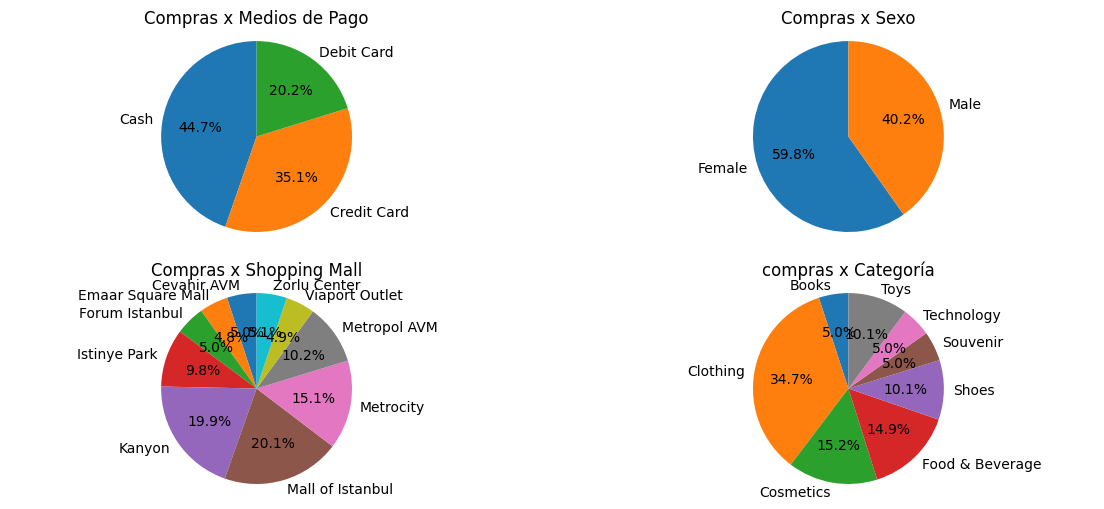

In [23]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 6))

#Distribución de Medios de Pago
axes[0,0].pie(df_payments, labels=df_payments.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Compras x Medios de Pago')
axes[0,0].axis('equal')

#Distribución de Genero
axes[0,1].pie(df_gender, labels=df_gender.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Compras x Sexo')
axes[0,1].axis('equal')

#Distribución de Shoppings
axes[1,0].pie(df_mall, labels=df_mall.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Compras x Shopping Mall')
axes[1,0].axis('equal')

#Distribución de Categorías
axes[1,1].pie(df_categories, labels=df_categories.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('compras x Categoría')
axes[1,1].axis('equal')

plt.show()

En los gráficos anteriores se puede ver que el predominio de la compra en efectivo es notable vs el pago en débito, pero no tan alejado del crédito.

Claramente las mujeres son quienes más compran y en cuanto a los shoppings si bien el más predominante es el Mall de Istanbul, también Kanyon y Metrocity son otros shoppings con participación imporante en la venta.

Por último la tendencia marcada de compra de ropa es notoria, pero le siguen 3 categorías como ser Cosméticos, Comida y zapatos.

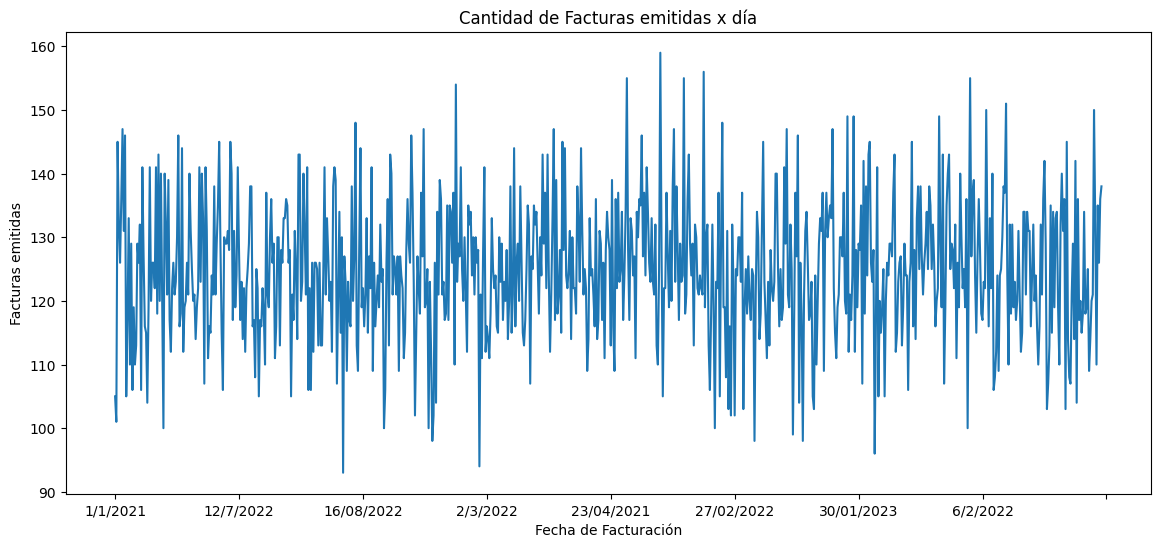

In [24]:
df_filtrado = df.groupby('invoice_date')['invoice_no'].count()
df_filtrado.plot(kind='line',figsize=(14,6),xlabel='Fecha de Facturación', ylabel='Facturas emitidas', title='Cantidad de Facturas emitidas x día')
plt.show()

Con el gráfico anterior se nota mucha variabilidad de facturas emitidas a lo largo de los días. Propongo agrupar por año, para evaluar el volumen total por año de facturas para ver el evolutivo del set de datos.

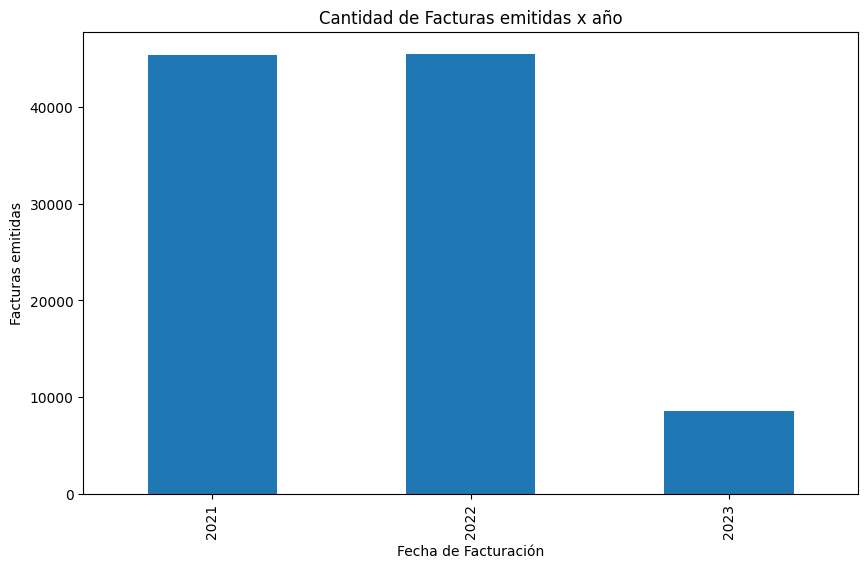

In [115]:
df['invoice_year'] = pd.to_datetime(df['invoice_date'],format='%d/%m/%Y').dt.year
df['invoice_month'] = pd.to_datetime(df['invoice_date'],format='%d/%m/%Y').dt.month
df['invoice_day'] = pd.to_datetime(df['invoice_date'],format='%d/%m/%Y').dt.day

df_filtrado = df['invoice_year'].value_counts().sort_index()
df_filtrado.plot(kind='bar',figsize=(10,6),xlabel='Fecha de Facturación', ylabel='Facturas emitidas', title='Cantidad de Facturas emitidas x año')
plt.show()

In [26]:
# Facturas emitidas por mes para el año 2023
df.where(df['invoice_year'] == 2023).groupby('invoice_month')['invoice_no'].count()

invoice_month
1.0    3926
2.0    3628
3.0     970
Name: invoice_no, dtype: int64

Como se puede ver la facturación anual es casi estable para el año 2021 y 2022, pero en el año 2023 es menor ya que sólo tenemos datos completos de enero y febrero, junto a un parcial de marzo.

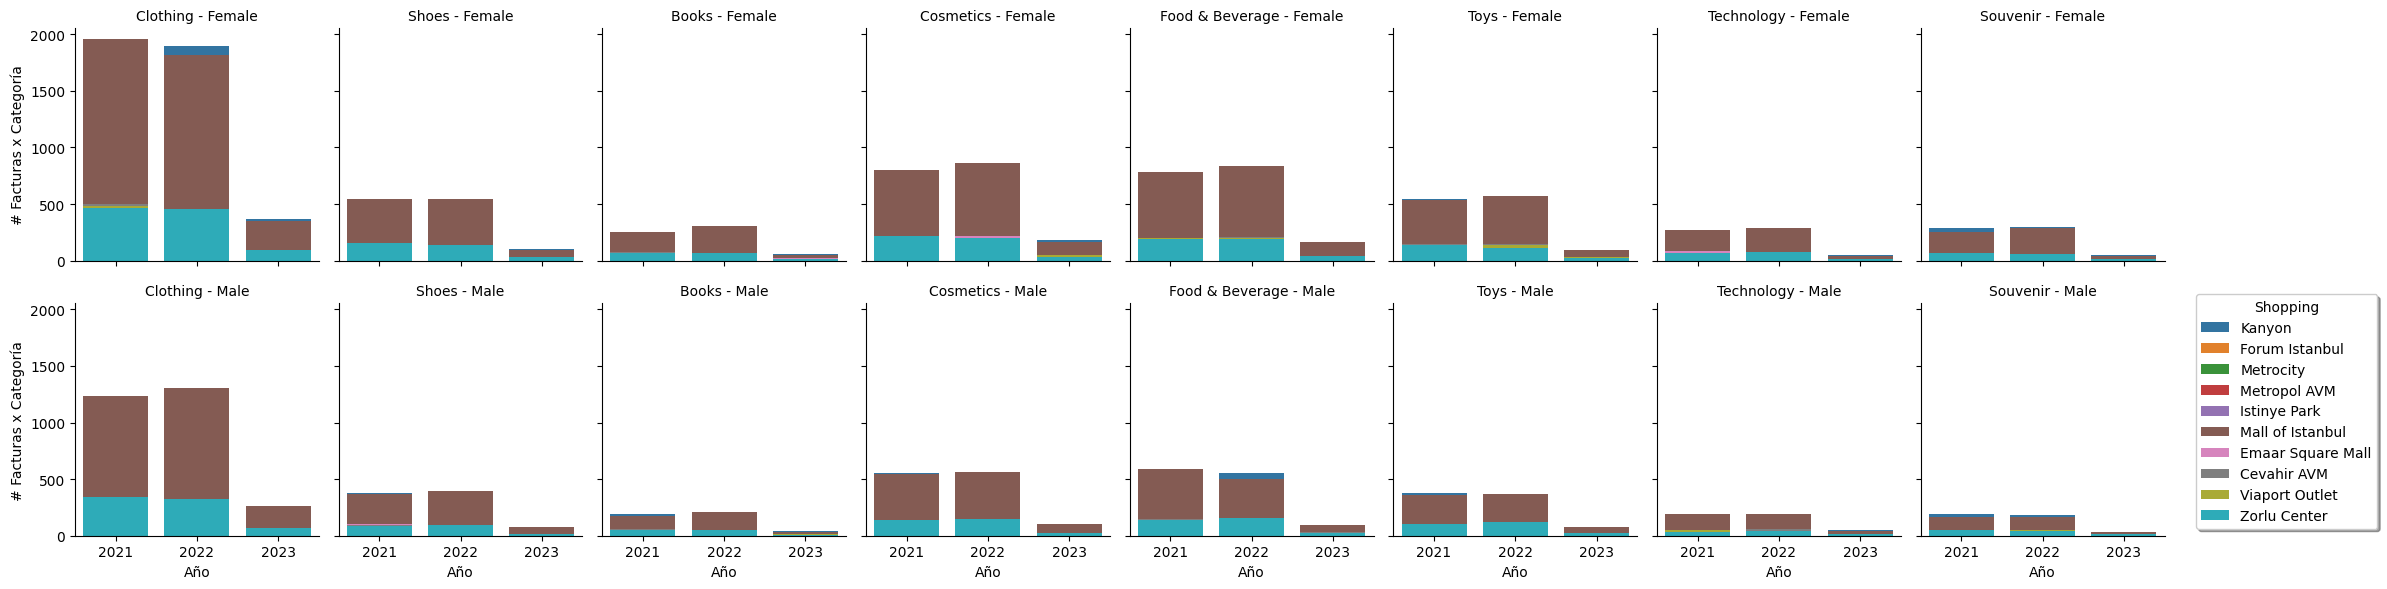

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

nd_años = df['invoice_year'].unique().sort()
nd_shoppings = df['shopping_mall'].unique()

g = sns.FacetGrid(df, col='category', row="gender",hue="shopping_mall")
g = g.map(sns.countplot,'invoice_year',order=nd_años)
g.set_axis_labels("Año", "# Facturas x Categoría")
g.set_titles("{col_name} - {row_name}")
plt.legend(title="Shopping",loc="lower left",bbox_to_anchor=(1.1, 0),fancybox=True, shadow=True, ncol=1)
plt.tight_layout()
plt.show()

Analizando el gráfico anterior, se puede ver la distribución de la cantidad de facturas por ampliada por categoría, sexo y destacando los shoppings.

Tal como se ve se pude ver como predomina la compra de las mujeres vs los hombres en todas las categorías, predominante en ropa, cosméticos y juguetens. Estabilizandose en el resto de las categorías.

En el año 2022, se destaca que para los hombres hubo más consumo YoY en Ropa y Zapatos vs las mujeres que sólo crecío YoY en Cosméticos, bebidas/comidas y juguentes.

## Modelo de Predicción
### Contexto Necesidad
Desde el área de marketing se desea poder predecir que clientes tienen más probabilidad de comprar en los próximos 30 días para enfocar las acciones de promoción sobre estos y así aumentar la efectividad de las campañas publicitarias.

### Hipótesis
Usando la información de 2 años anteriores es posible predecir con un 75% de precisión si un cliente va a comprar en los próximos 30 días.

### Tipo de Problema:
Clasificación basado en regresión logística porque lo que quiero deducir es un valor de probabilidad sobre uno o varios clientes según su código de identificación único.

### Análisis previo a la generación del modelo
1. El dataset no contiene datos de promociones aplicadas sobre los productos comprados.
2. El dataset no contiene datos de estacionalidad conocida dentro de los datos transaccionales de compra.
3. Vamos a usar la transformación "One Hot Encoding" para pasar las categóricas a numéricas (Shopping, Categoría, Medio de Pago, género).
4. Antes de aplicar la regresión logistica vamos a generar un dataset con rangos de fechas de los últmos 2 años cortando cada 90 días y al llegar a 90 días previos hacemos cortes más cercanos (ventas_ultimos_720,ventas_ultimos_630,ventas_ultimos_540,ventas_ultimos_450,ventas_ultimos_360,ventas_ultimos_270,ventas_ultimos_180,ventas_ultimos_90,ventas_ultimos_60,ventas_ultimos_30,ventas_ultimos_15,ventas_ultimos_7). Esto simplemente para tener rangos históricos que sirvan al modelo para predecir.
5. Para cada rango de ventas históricas que se generó, se suma la etiqueta ventas_proximos_30 que nos dice si se generó una venta de ese producto.
6. Para calcular la fecha de corte del análisis, veremos cual es la última fecha de venta que tenemos en el dataset, de manera que esa sea nuestra fecha máxima de análisis y desde ahí hacemos los cortes hacia atrás.

Comienzo aplicando **One Hot Encoding** para las variables categóricas.

In [116]:
#Primero procedo a sacarle las columnas innecesarias como ser el número de factura
df.drop(columns=["invoice_no"],inplace=True)

#Luego acomodo el id de cliente ya que es una categórica y la paso a INT
df['customer_id'] = df['customer_id'].replace('C','',regex=True).astype('Int64')

df.head()

,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,invoice_year,invoice_month,invoice_day
0,241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,2022,8,5
1,111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,2021,12,12
2,266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,2021,11,9
3,988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,2021,5,16
4,189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,2021,10,24


In [112]:
df_encoded = pd.get_dummies(df, columns=['category', 'shopping_mall','gender','payment_method'], drop_first=True)

#Veo como quedaron las nuevas columnas preparadas para el análisis.
df_encoded.head()

,customer_id,age,quantity,price,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,...,shopping_mall_Istinye Park,shopping_mall_Kanyon,shopping_mall_Mall of Istanbul,shopping_mall_Metrocity,shopping_mall_Metropol AVM,shopping_mall_Viaport Outlet,shopping_mall_Zorlu Center,gender_Male,payment_method_Credit Card,payment_method_Debit Card
0,241288,28,5,1500.40,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,111565,21,3,1800.51,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,True
2,266599,20,1,300.08,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,988172,66,5,3000.85,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
4,189076,53,4,60.60,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [129]:
#Fecha máxima desde la cual controlo
fecha_hasta = df['invoice_date'].max()
print('Máxima Fecha Control: ',fecha_hasta)
fecha_hasta_datetime = pd.to_datetime(fecha_hasta,format="%d/%m/%Y")

Máxima Fecha Control:  9/9/2022


In [130]:
fecha_control = fecha_hasta_datetime - pd.DateOffset(months=1)
print(fecha_control)

2022-08-09 00:00:00


In [137]:
#Armo las ventanas de tiempo
df_new = df.where(df['invoice_date'] >= fecha_control.strftime('%d/%m/%Y')).groupby(['customer_id','category','shopping_mall'])['quantity'].sum()
df_new.head()

customer_id  category         shopping_mall
100004       Clothing         Metrocity        5
100005       Shoes            Kanyon           2
100006       Toys             Cevahir AVM      3
100012       Food & Beverage  Kanyon           5
100019       Toys             Metrocity        1
Name: quantity, dtype: int64

Me queda pendiente hacer los grupos por las demás ventanas y luego hacer el one hot pero posterior a las ventanas.